In [5]:
import os
env = os.environ.get("MLFLOW_TRACKING_URI", "http://localhost:5000")
env



'http://mlflow:5000'

In [ ]:
# Installer pandas avec les magics Jupyter si besoin
%pip install pandas
# Si tu utilises conda, tu peux aussi essayer :
# %conda install pandas

In [ ]:
# Installer pandas avec les magics Jupyter si besoin
%pip install pandas tensorflow
from tensorflow import keras

(X, y), (x_test, y_test) = keras.datasets.mnist.load_data()
import pandas as pd
# import matplotlib.pyplot as plt
import numpy as np



X_df = pd.DataFrame(X.reshape(X.shape[0], -1))
# X_df = X_df.drop_duplicates()
y_df = pd.DataFrame(y, columns=['target'])
print("Shape of X_df:", X_df.shape)
print("Shape of y_df:", y_df.shape)


Shape of X_df: (60000, 784)
Shape of y_df: (60000, 1)


In [6]:
# sauvegarde des données dans le dossier data
import os
os.makedirs("./data", exist_ok=True)
df_full = X_df.copy()
df_full['target'] = y_df['target']
df_full.to_csv("./data/mnist_full.csv", index=False)
print("Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.")

Données MNIST sauvegardées dans le fichier mnist_full.csv du dossier data.


In [22]:
import pandas as pd
import sys

# Charger le fichier CSV
file_path = "./data/mnist_full.csv"
df = pd.read_csv(file_path)

def showimg(df, index):
    if index < 0 or index >= len(df):
        print(f"Index {index} hors limites (0-{len(df)-1})")
        sys.exit(1)

    row = df.iloc[index]
    X = row.drop('target').values.reshape(28, 28)
    y = row['target']

    print(f"Label (target) : {y}")

    try:
        import matplotlib.pyplot as plt
        plt.imshow(X, cmap='gray')
        plt.title(f"Index {index} - Label: {y}")
        plt.axis('off')
        plt.show()
    except ImportError:
        print("matplotlib n'est pas installé, affichage image impossible.")
   

Label (target) : 7


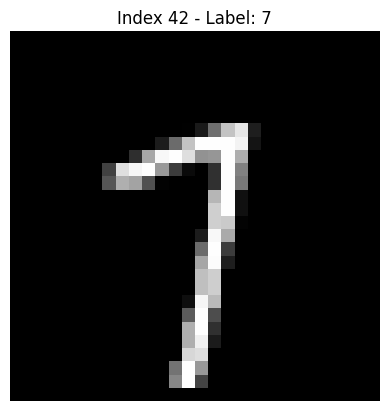

In [23]:
showimg(df, 42)

In [26]:
from models.keras_mnist_models import (
    create_nn_model,
    train_model,
    model_predict,
    model_evaluate,
    model_preprocess
)

In [ ]:
# maj des imports pour éviter les erreurs de module introuvable
import importlib
import models.keras_mnist_models
importlib.reload(models.keras_mnist_models)
from models.keras_mnist_models import model_preprocess

In [13]:
df.describe()


,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0,60000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0,4.453933
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0,2.889270
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,2.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,4.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0,7.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0,9.000000


In [31]:
X, y, _ = model_preprocess(df)

In [ ]:
X.describe()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
count,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000348,0.000179,0.000076,0.000059,0.000008,0.0,0.0,0.0,0.0,0.017466
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.015514,0.011137,0.006615,0.006582,0.001359,0.0,0.0,0.0,0.0,0.011330
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.007843
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.015686
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.027451
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.996078,0.992157,0.992157,0.996078,0.243137,0.0,0.0,0.0,0.0,0.035294


In [29]:
import pandas as pd
df_corr = pd.read_csv("./data/user_corrections.csv")

In [30]:
classes_to_retrain = [3]  # Classes à réentraîner]
df_corr = df_corr[df_corr['correction'].isin(classes_to_retrain)]
df_corr

,image_bytes,pred,correction
0,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
1,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
2,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
3,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
4,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
5,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
6,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
7,89504e470d0a1a0a0000000d494844520000001c000000...,2,3


Label (target) : 3


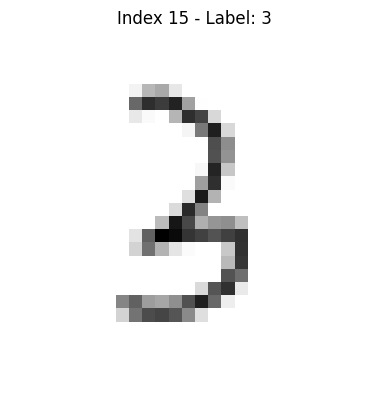

In [57]:
# df_img = df_corr['image_bytes'].apply(lambda x: np.frombuffer(bytes.fromhex(x), dtype=np.uint8).reshape(28, 28))
df_img = df_corr['image_bytes']
df_img = df_corr.drop(['pred'], axis=1, errors='ignore')
#rename colomn correction => target
df_img = df_img.rename(columns={'correction': 'target'})


from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import io

df_tmp = df_img.copy()





def increase_correction(df_corr, n_aug=1, rotation_range=15):
    """
    Pour chaque image hexadécimale, génère n_aug images augmentées par rotation (ImageDataGenerator).
    Retourne un DataFrame format MNIST (784 colonnes de pixels + target).
    """
    pixel_columns = [f"px_{i}" for i in range(28*28)]
    data = []
    datagen = ImageDataGenerator(rotation_range=rotation_range)
    
    for idx, row in df_corr.iterrows():
        hex_str = row["image_bytes"]
        target = row["target"]
        # Décoder l'image hexadécimale
        img_bytes = bytes.fromhex(hex_str)
        img = Image.open(io.BytesIO(img_bytes)).convert("L").resize((28, 28))
        arr = np.array(img)
        # Ajouter l'originale
        data.append(np.append(arr.flatten(), target))
        # Générer des images augmentées
        arr_expanded = arr.reshape((1, 28, 28, 1)) / 255.0  # normalisé pour ImageDataGenerator
        aug_iter = datagen.flow(arr_expanded, batch_size=1)
        for _ in range(n_aug):
            arr_aug = next(aug_iter)[0]  # shape (28,28,1), valeurs [0,1]
            arr_aug = (arr_aug * 255).astype(np.uint8).reshape(28, 28)
            data.append(np.append(arr_aug.flatten(), target))
    df_final = pd.DataFrame(data, columns=pixel_columns + ["target"])
    return df_final

       
# df_tmp
# df_ready = increase_correction_01(df_tmp)
df_ready = increase_correction(df_tmp, n_aug=2, rotation_range=10)
showimg(df_ready, 15)
        
        



In [55]:
print("df_tmp shape:", df_tmp.shape)
print("df_ready shape:", df_ready.shape)

df_tmp shape: (8, 2)
df_ready shape: (24, 785)


Label (target) : 3


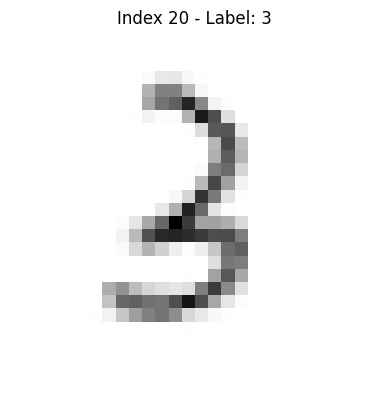

In [59]:
showimg(df_ready, 20)

In [56]:
df_ready

,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_775,px_776,px_777,px_778,px_779,px_780,px_781,px_782,px_783,target
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
5,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
6,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
7,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
8,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3
9,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3


In [53]:
df_tmp

,image_bytes,target
0,89504e470d0a1a0a0000000d494844520000001c000000...,3
1,89504e470d0a1a0a0000000d494844520000001c000000...,3
2,89504e470d0a1a0a0000000d494844520000001c000000...,3
3,89504e470d0a1a0a0000000d494844520000001c000000...,3
4,89504e470d0a1a0a0000000d494844520000001c000000...,3
5,89504e470d0a1a0a0000000d494844520000001c000000...,3
6,89504e470d0a1a0a0000000d494844520000001c000000...,3
7,89504e470d0a1a0a0000000d494844520000001c000000...,3


In [15]:
import numpy as np
import pandas as pd
from PIL import Image
import io
# Supposons que df_corr['image_bytes'] contient les chaînes de pixels
def parse_pixel_string(val):
    # Si la chaîne contient des virgules, c'est une liste de pixels
    if ',' in val:
        return np.array([int(x) for x in val.split(',')], dtype=np.uint8)
    else:
        # Sinon, c'est une image hexadécimale PNG
        img_bytes = bytes.fromhex(val)
        img = Image.open(io.BytesIO(img_bytes)).convert("L").resize((28, 28))
        return np.array(img).flatten()

# Appliquer à toute la colonne
pixel_columns = [f"px_{i}" for i in range(28*28)]
df_pixels = pd.DataFrame(df_corr['image_bytes'].apply(parse_pixel_string).tolist(), columns=pixel_columns)

# Fusionner avec les autres colonnes utiles (ex: 'pred', 'correction')
df_corr_final = pd.concat([df_pixels, df_corr.drop(columns=['image_bytes'])], axis=1)
df_corr_final





,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_776,px_777,px_778,px_779,px_780,px_781,px_782,px_783,pred,correction
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
5,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
6,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3
7,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,2,3


In [28]:
df_y = df_corr_final['correction']
df_y
df_X = df_corr_final.drop(['correction', 'pred'], axis=1, errors='ignore')
df_X

,px_0,px_1,px_2,px_3,px_4,px_5,px_6,px_7,px_8,px_9,...,px_774,px_775,px_776,px_777,px_778,px_779,px_780,px_781,px_782,px_783
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
1,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
2,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
3,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
4,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
5,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
6,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255
7,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,255


In [16]:
df_base = pd.read_csv("./data/mnist_full.csv").head(5)
df_base

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


In [20]:
df_corr_final2 = df_corr_final.drop(columns=['correction', 'pred']).values.astype("float32") / 255.0
df_corr_final2

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [17]:
df2 = pd.concat([df_base, df_corr_final], ignore_index=True)
df2

,0,1,2,3,4,5,6,7,8,9,...,px_776,px_777,px_778,px_779,px_780,px_781,px_782,px_783,pred,correction
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,2.0,3.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,2.0,3.0
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,2.0,3.0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,2.0,3.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,255.0,255.0,255.0,255.0,255.0,255.0,255.0,255.0,2.0,3.0


In [1]:
import requests
import sys
import os

import numpy as np
import pandas as pd
from PIL import Image
import io



# sys.path.insert(0, os.path.abspath(os.path.dirname(__file__) + "/.."))
from modules.mnist import increase_correction

payload = {
    "classes": [3],
    "corrections_path": "./data/user_corrections.csv",
    "base_data_path": "./data/mnist_full.csv"
}


 # Charger les données (base + corrections)
df_base = pd.read_csv(payload['base_data_path'])
df_corr = pd.read_csv(payload['corrections_path'])
classes_to_retrain = payload['classes'] 

# Filtrer les corrections pour ne garder que celles des classes à réentraîner
if classes_to_retrain:
    df_corr = df_corr[df_corr['correction'].isin(classes_to_retrain)]
    # if df_corr.empty:
    #     return JSONResponse({"status": "success", "message": "Aucune correction à réentraîner pour les classes spécifiées."}, status_code=200)

# clean et augmente le dataset de corrections
df_img = df_corr['image_bytes']
df_img = df_corr.drop(['pred'], axis=1, errors='ignore')
#rename colomn correction => target
df_img = df_img.rename(columns={'correction': 'target'})
df_clean_correction = increase_correction(df_img, n_aug=1, rotation_range=15)



In [15]:
# from modules.mnist import increase_correction
# df_clean_correction = increase_correction(df_img, n_aug=1, rotation_range=15)
df_clean_correction = df_clean_correction.rename(columns={i: str(i) for i in range(784)})
df_clean_correction = df_clean_correction[df_base.columns]
df_clean_correction.head(1)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,255,255,255,255,255,255,255,255,255,255,...,255,255,255,255,255,255,255,255,255,3


In [3]:
df_base.head(1)

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,target
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5


In [13]:
df = pd.concat([df_base, df_clean_correction], ignore_index=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60016 entries, 0 to 60015
Columns: 785 entries, 0 to target
dtypes: int64(785)
memory usage: 359.4 MB


In [9]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, 0 to target
dtypes: int64(785)
memory usage: 359.3 MB


In [11]:
df_clean_correction.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Columns: 785 entries, 0 to target
dtypes: int64(785)
memory usage: 98.2 KB


In [16]:
 # Reshape X pour le modèle Keras (n, 28, 28, 1)
X = df.drop(['target'], axis=1, errors='ignore').values.astype("float32") / 255.0
X = X.reshape(-1, 28, 28, 1)
y = df['target']

In [27]:
from tensorflow.keras.utils import to_categorical
y_cat = to_categorical(y, num_classes=10)

In [29]:
y

0        5
1        0
2        4
3        1
4        9
        ..
60011    3
60012    3
60013    3
60014    3
60015    3
Name: target, Length: 60016, dtype: int64

In [18]:
import optuna
study = optuna.create_study(direction="maximize")

e:\01_WORKS\00_wip\7SHAPES\simplon\mod6_1\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-07-12 09:16:59,548] A new study created in memory with name: no-name-9650f079-95b2-4d80-925e-2e96062154ec


In [30]:
from models.keras_mnist_models import model_predict, model_preprocess, create_nn_model
from sklearn.model_selection import train_test_split
def train_and_validate(model, X, y, epochs=5, batch_size=32):
    from sklearn.model_selection import train_test_split
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
    hist = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=epochs, batch_size=batch_size, verbose=0)
    loss, accuracy = model.evaluate(X_val, y_val, verbose=0)
    return accuracy

def objective(trial):
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    dropout = trial.suggest_float("dropout", 0.1, 0.5)
    model = create_nn_model(lr=lr, dropout=dropout)
    accuracy = train_and_validate(model, X, y_cat)
    return accuracy

In [32]:
study.optimize(objective, n_trials=5)
# Après Optuna, entraîner le modèle final avec les meilleurs params
best_params = study.best_params

[I 2025-07-12 09:31:25,819] Trial 11 finished with value: 0.9716761112213135 and parameters: {'lr': 0.00022215867668019972, 'dropout': 0.3603775871758076}. Best is trial 1 with value: 0.9835888147354126.
[I 2025-07-12 09:32:02,370] Trial 12 finished with value: 0.9837554097175598 and parameters: {'lr': 0.0007199302452088205, 'dropout': 0.1172415955035431}. Best is trial 12 with value: 0.9837554097175598.
[I 2025-07-12 09:32:37,523] Trial 13 finished with value: 0.9836720824241638 and parameters: {'lr': 0.0010116452392577478, 'dropout': 0.12226977849594112}. Best is trial 12 with value: 0.9837554097175598.
[I 2025-07-12 09:33:13,749] Trial 14 finished with value: 0.9803398847579956 and parameters: {'lr': 0.000815426929811207, 'dropout': 0.10636724679441557}. Best is trial 12 with value: 0.9837554097175598.
[I 2025-07-12 09:33:49,066] Trial 15 finished with value: 0.9826724529266357 and parameters: {'lr': 0.0007807937738985742, 'dropout': 0.11331401183359274}. Best is trial 12 with value

In [39]:
from models.keras_mnist_models import model_predict, model_preprocess, create_nn_model
model = create_nn_model(**best_params)
accuracy = train_and_validate(model, X, y_cat)

In [ ]:
artifact_path = "mnist_model"
import mlflow
mlflow.set_experiment(artifact_path)

with mlflow.start_run() as run:
            # Prétraitement pour MLflow (reshape, normalisation, one-hot)
            # X_proc, y_proc, _ = model_preprocess(df)
            # model = create_nn_model(**best_params)
            # accuracy = train_and_validate(model, X, y_cat)
            model.fit(X, y_cat, epochs=5, batch_size=32, verbose=0)
            # Évaluer la précision sur l'ensemble d'entraînement (ou valider selon besoin)
            loss, accuracy = model.evaluate(X, y_cat, verbose=0)
            # Log du modèle
            mlflow.keras.log_model(model, "model")
            mlflow.log_params(best_params)
            mlflow.log_metric("accuracy", accuracy)
            run_id = run.info.run_id
            # set_last_run_id(run_id)
            # logger.info(f"Modèle loggué dans MLflow avec run_id={run_id}")

2025/07/12 09:56:51 INFO mlflow.tracking.fluent: Experiment with name 'mnist_model' does not exist. Creating a new experiment.
2025/07/12 09:57:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/07/12 09:57:34 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.
2025/07/12 09:57:56 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


In [45]:
df_traited = df_corr[df_corr['correction'].isin(classes_to_retrain)]
df_corr = df_corr[~df_corr['correction'].isin(classes_to_retrain)]

In [46]:
df_corr

,image_bytes,pred,correction


In [43]:
df_corr = pd.read_csv(payload['corrections_path'])

In [47]:
df_traited

,image_bytes,pred,correction
0,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
1,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
2,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
3,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
4,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
5,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
6,89504e470d0a1a0a0000000d494844520000001c000000...,2,3
7,89504e470d0a1a0a0000000d494844520000001c000000...,2,3


In [48]:
path_to_user_traited = "./data/mnist_trained.csv"
df_traited.to_csv(path_to_user_traited, index=False)